In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("product_info.csv")
df.head()

,user_id,timestamp,variant,device,country,traffic_source,new_user,pages_viewed,session_duration_sec,converted,order_value,revenue
0,1,2025-02-05 20:00:00,A,Desktop,India,Social,0,5,64,1,95.05,95.05
1,2,2025-06-07 04:00:00,A,Desktop,India,Social,1,9,206,0,0.00,0.00
2,3,2025-05-09 20:00:00,B,Desktop,USA,Organic,1,9,226,0,0.00,0.00
3,4,2025-01-20 10:00:00,A,Desktop,India,Organic,1,7,154,0,0.00,0.00
4,5,2025-05-24 12:00:00,A,Desktop,UK,Organic,1,4,116,0,0.00,0.00


In [6]:
total_users = len(df)

print("Total Users:", total_users)

Total Users: 100000


In [4]:
device_counts = df["device"].value_counts()

print(device_counts)

device
Mobile     45122
Desktop    44795
Tablet     10083
Name: count, dtype: int64


In [7]:
variant_counts = df['variant'].value_counts()

print(variant_counts)

variant
B    50143
A    49857
Name: count, dtype: int64


In [8]:
variant_counts = (
    df.groupby('variant')
      .size()
      .reset_index(name='Users')
)

print(variant_counts)

  variant  Users
0       A  49857
1       B  50143


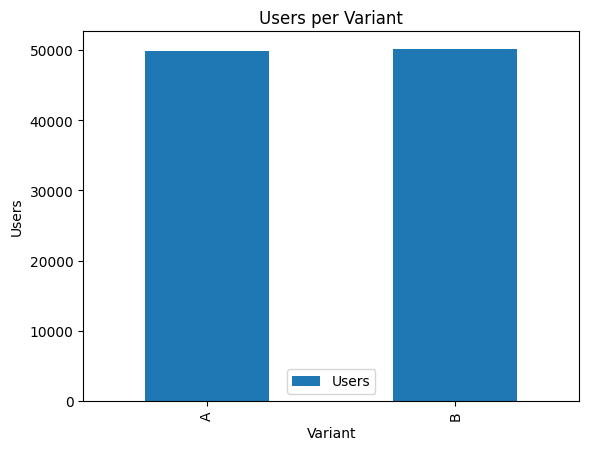

In [10]:
variant_counts.plot(
    x='variant',
    y='Users',
    kind='bar'
)

plt.title("Users per Variant")
plt.xlabel("Variant")
plt.ylabel("Users")

plt.show()

In [11]:
conversion = (
    df.groupby('variant')['converted']
      .agg(['count','sum'])
)

conversion.columns = ['Visitors','Conversions']

conversion['Conversion Rate'] = (
    conversion['Conversions']
    /
    conversion['Visitors']
)*100

print(conversion)

         Visitors  Conversions  Conversion Rate
variant                                        
A           49857         5676        11.384560
B           50143         6462        12.887143


In [3]:
print(df.columns.tolist())

['user_id', 'timestamp', 'variant', 'device', 'country', 'traffic_source', 'new_user', 'pages_viewed', 'session_duration_sec', 'converted', 'order_value', 'revenue']


In [10]:
## Which variant generated more total revenue?--

revenue = (df.groupby("variant")["revenue"].sum().reset_index())
print(revenue)

  variant    revenue
0       A  426463.18
1       B  485831.97


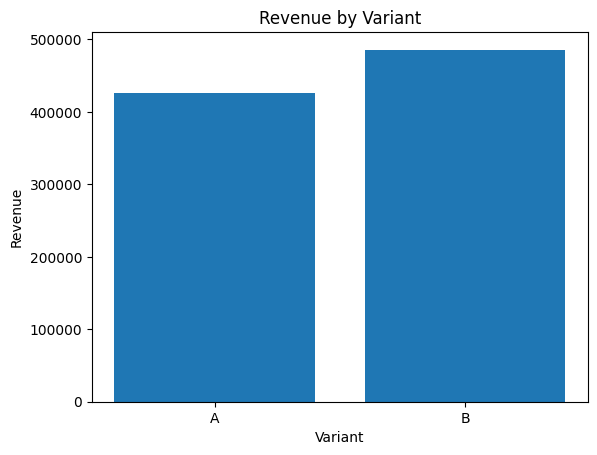

In [13]:
plt.bar(revenue['variant'],revenue['revenue'])

plt.title("Revenue by Variant")

plt.xlabel("Variant")

plt.ylabel("Revenue")

plt.show()

In [14]:
## What is the Average Order Value (AOV) for each variant?

aov = (
    df[df['converted']==1]
    .groupby('variant')['order_value']
    .mean()
    .reset_index()
)

print(aov)

  variant  order_value
0       A    75.134457
1       B    75.182911


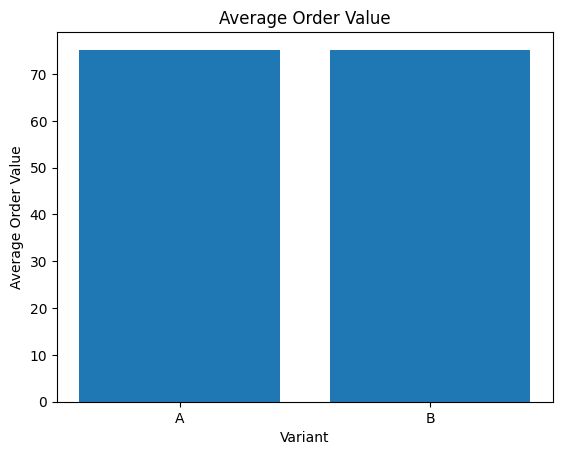

In [15]:
plt.bar(aov['variant'], aov['order_value'])

plt.title("Average Order Value")

plt.xlabel("Variant")

plt.ylabel("Average Order Value")

plt.show()

In [16]:
## What is the Average Revenue Per User (ARPU) for each variant?

arpu = (
    df.groupby("variant")["revenue"]
      .mean()
      .reset_index()
      .rename(columns={"revenue":"ARPU"})
)

print(arpu)

  variant      ARPU
0       A  8.553727
1       B  9.688929


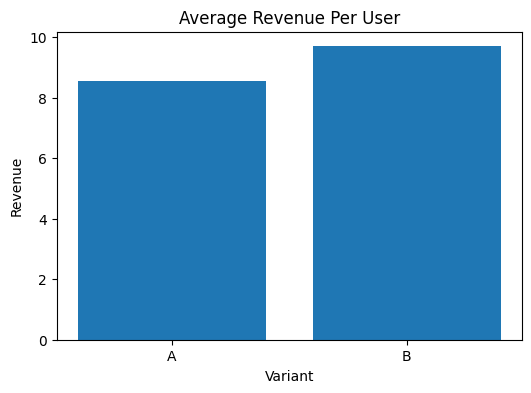

In [17]:
plt.figure(figsize=(6,4))

plt.bar(arpu["variant"], arpu["ARPU"])

plt.title("Average Revenue Per User")

plt.xlabel("Variant")
plt.ylabel("Revenue")

plt.show()